## **Capstone Project 3**
# Smart Marketing Prediction System (ML Pipeline Project)
Scenario
 # A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

Currently:

Many customers browse but never purchase

Marketing money is wasted on the wrong users

The company wants to predict purchase probability

The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

If the system predicts high probability of purchase, the system will:

show personalized product recommendations

offer targeted discounts

prioritize marketing campaigns

If the system predicts low probability, the company will avoid spending marketing resources.

However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.

Dataset is available in DatasetCapstoneProject3 in the github repo link https://github.com/himanshusar123/Datasets

Business Objective
Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

The model must be implemented using scikit-learn pipelines, including:

Encoding techniques

Feature preprocessing

Model training

Model selection

Hyperparameter tuning

Dataset Preview
   CustomerID  Age  Gender   Device  Traffic_Source  Time_on_Website  \
0           1   23    Male   Mobile    Social Media                5   
1           2   35  Female  Desktop   Search Engine               12   
2           3   29    Male   Tablet    Social Media                8   
3           4   41  Female   Mobile  Email Campaign               15   
4           5   22  Female  Desktop          Direct                4   

   Pages_Visited  Ad_Clicks  Previous_Purchases  Purchased  
0              3          1                   0          0  
1              8          3                   2          1  
2              5          2                   1          0  
3             10          4                   3          1  
4              2          0                   0          0  


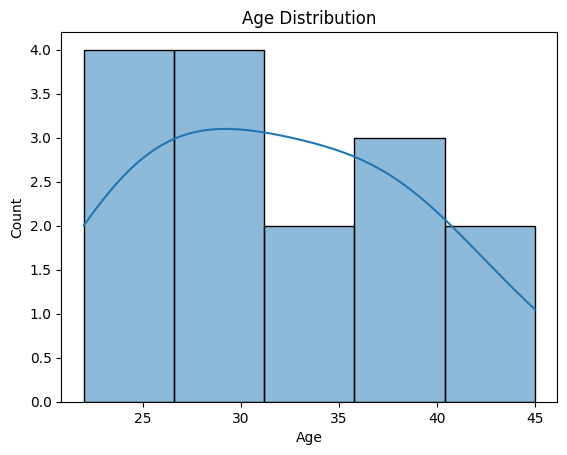

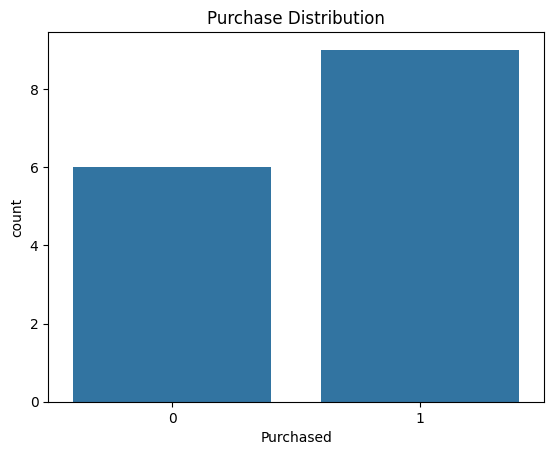

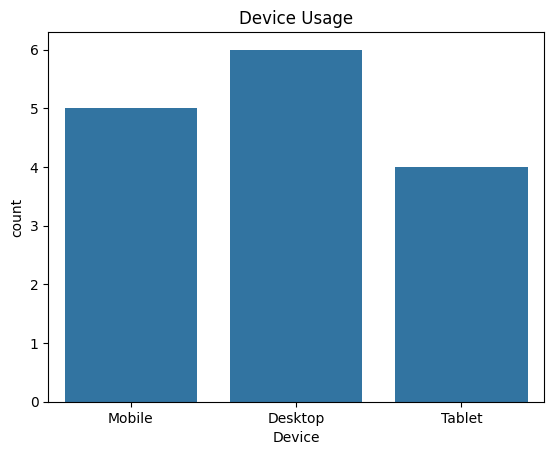

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'model__max_depth': None, 'model__n_estimators': 50}
Model Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



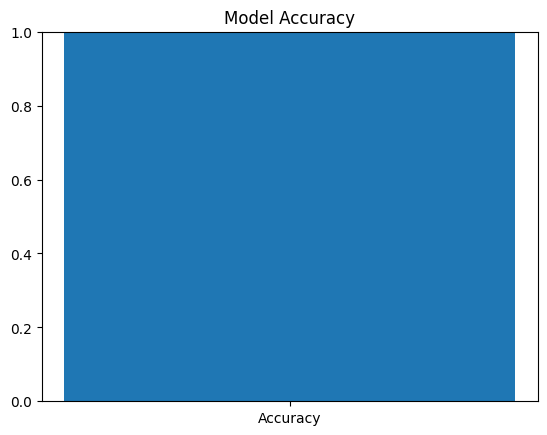

Feature Importance
                          Feature  Importance
0                             Age    0.196677
1                 Time_on_Website    0.189155
2                   Pages_Visited    0.185000
4              Previous_Purchases    0.175111
3                       Ad_Clicks    0.074286
13    Traffic_Source_Social Media    0.067636
11  Traffic_Source_Email Campaign    0.044956
12   Traffic_Source_Search Engine    0.023667
8                   Device_Mobile    0.014603
7                  Device_Desktop    0.013909
9                   Device_Tablet    0.009000
10          Traffic_Source_Direct    0.006000
5                   Gender_Female    0.000000
6                     Gender_Male    0.000000


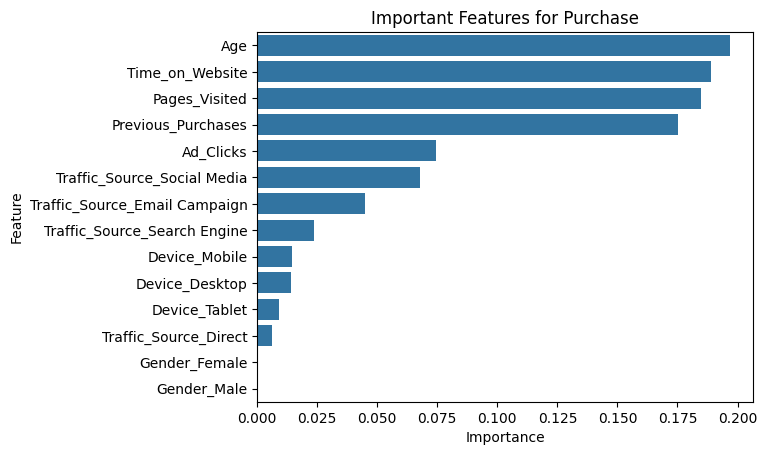

Prediction: 0
Purchase Probability: [[0.74 0.26]]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


data = pd.read_excel("DatasetCapstoneProject3.xlsx")

print("Dataset Preview")
print(data.head())


sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.countplot(x='Purchased', data=data)
plt.title("Purchase Distribution")
plt.show()

sns.countplot(x='Device', data=data)
plt.title("Device Usage")
plt.show()


X = data.drop(["Purchased", "CustomerID"], axis=1)
y = data["Purchased"]


num_features = [
'Age',
'Time_on_Website',
'Pages_Visited',
'Ad_Clicks',
'Previous_Purchases'
]

cat_features = [
'Gender',
'Device',
'Traffic_Source'
]


preprocessor = ColumnTransformer([
("num", StandardScaler(), num_features),
("cat", OneHotEncoder(handle_unknown='ignore'), cat_features)
])


pipeline = Pipeline([
("preprocess", preprocessor),
("model", RandomForestClassifier(random_state=42))
])


X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)


params = {
"model__n_estimators":[50,100],
"model__max_depth":[None,10]
}

grid = GridSearchCV(pipeline, params, cv=5)

grid.fit(X_train, y_train)


y_pred = grid.predict(X_test)

print("Best Parameters:", grid.best_params_)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, y_pred))


plt.bar(["Accuracy"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()


model = grid.best_estimator_.named_steps["model"]

feature_names = num_features + list(
grid.best_estimator_
.named_steps["preprocess"]
.named_transformers_["cat"]
.get_feature_names_out(cat_features)
)

importance = model.feature_importances_

imp_df = pd.DataFrame({
"Feature":feature_names,
"Importance":importance
}).sort_values(by="Importance",ascending=False)

print("Feature Importance")
print(imp_df)

sns.barplot(x="Importance",y="Feature",data=imp_df)
plt.title("Important Features for Purchase")
plt.show()


new_customer = pd.DataFrame({
'Age':[30],
'Gender':['Male'],
'Device':['Mobile'],
'Traffic_Source':['Social Media'],
'Time_on_Website':[12],
'Pages_Visited':[5],
'Ad_Clicks':[2],
'Previous_Purchases':[1]
})

prediction = grid.predict(new_customer)
probability = grid.predict_proba(new_customer)

print("Prediction:", prediction[0])
print("Purchase Probability:", probability)

## **Capstone Project 4**
Project Scenario
# Smart Traffic Sign Recognition System
Scenario
A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

1️⃣ First, the system must understand basic classification logic (learning from features).
2️⃣ Second, it must classify images of traffic signs captured by cameras.

To solve this, the engineering team decided to build the system in two stages.

Stage 1
Learning Basic Neural Networks (Perceptron)
Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.



Dataset is available in DatasetCapstoneProject4 in the github repo link https://github.com/himanshusar123/Datasets

In [19]:
import torch
import torch.nn as nn
import pandas as pd
from google.colab import files


# Upload dataset
print("Upload Dataset")
uploaded = files.upload()

# Read uploaded CSV file
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Preview")
print(df.head())


# Separate features and target
X = df.drop(['Sign_ID','Stop_Sign'],axis=1)
y = df['Stop_Sign']


# Creating the Perceptron
class Perceptron(nn.Module):

    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(X.shape[1], 1)   # it automatically matches feature count

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


model = Perceptron()

learning_rate = 0.1


# Training loop
for epoch in range(100):

    for i in range(len(X)):

        xi = torch.tensor(X.iloc[i].values, dtype=torch.float32)
        target = torch.tensor(y.iloc[i], dtype=torch.float32)

        output = model(xi)

        prediction = 1 if output >= 0.5 else 0
        error = target - prediction

        with torch.no_grad():
            model.linear.weight += learning_rate * error * xi
            model.linear.bias += learning_rate * error

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} completed")


# Random test traffic sign
test = torch.tensor([0.9,0.85,1,0], dtype=torch.float32)

result = model(test)


# Display prediction
if result >= 0.5:
    print("Traffic sign is STOP")
else:
    print("Traffic sign is NOT STOP")


print("\nPrediction Probability:", result.item())
print("Predicted Class:", 1 if result>=0.5 else 0)

Upload Dataset


Saving DatasetCapstoneProject4.csv to DatasetCapstoneProject4 (9).csv
Dataset Preview
   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  
Epoch 10 completed
Epoch 20 completed
Epoch 30 completed
Epoch 40 completed
Epoch 50 completed
Epoch 60 completed
Epoch 70 completed
Epoch 80 completed
Epoch 90 completed
Epoch 100 completed
Traffic sign is NOT STOP

Prediction Probability: 0.23054909706115723
Predicted Class: 0
